# 实验四：统计语言模型 (N-gram)

## 第一部分：二元语法模型与句子概率

In [13]:
def bigrams(sequence, pad_left=False, pad_right=False, pad_symbol=None):
    """
    从一个序列中生成二元组 (bigrams)。
    Args:
        sequence: 词列表。
        pad_left: 是否在句首添加填充符。
        pad_right: 是否在句尾添加填充符。
        pad_symbol: 用于填充的符号。
    Returns:
        一个包含二元组的生成器 (generator)。
    """
    sent = list(sequence)
    if pad_left:
        sent.insert(0, pad_symbol)
    if pad_right:
        sent.append(pad_symbol)
    for i in range(len(sent) - 1):
        yield (sent[i], sent[i+1])

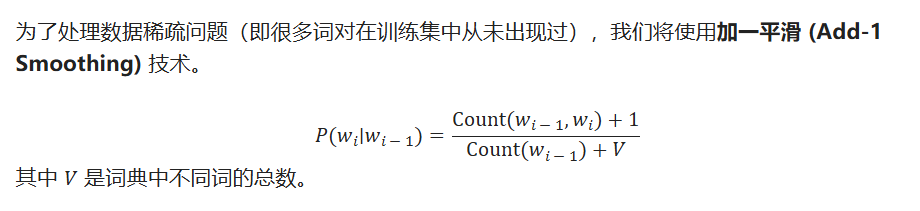

In [14]:
import os
from collections import defaultdict
from math import log, exp
# --- 数据文件路径定义 ---
sighan05 = "./corpus_data/第二届国际中文分词评测/icwb2-data/"
msr_train = os.path.join(sighan05, 'training', 'msr_training.utf8')
msr_gold = os.path.join(sighan05, 'gold', 'msr_test_gold.utf8')
# --- 训练二元模型 ---
# bigram_counts: 存储 Count(w1, w2)，格式: {w1: {w2: count}}
# unigram_counts: 存储 Count(w)，格式: {w: count}
bigram_counts = defaultdict(lambda: defaultdict(int))
unigram_counts = defaultdict(int)
print("开始训练二元模型...")
with open(msr_train, encoding="utf-8") as f:
    # 1. 读取并预处理句子
    sents = [line.strip().split("  ") for line in f if line.strip()]
    # 添加句子开始<BOS>和结束<EOS>标记
    sents = [['<BOS>'] + sent + ['<EOS>'] for sent in sents]
    # 2. 统计频次
    for sent in sents:
        for w1, w2 in bigrams(sent):
            bigram_counts[w1][w2] += 1
        for w in sent:
            unigram_counts[w] += 1
            
# 词典大小 V
vocab_size = len(unigram_counts)
# 3. 计算加一平滑后的条件概率
# bigram_probs: 存储 P(w2 | w1)
bigram_probs = defaultdict(lambda: defaultdict(float))
for w1 in bigram_counts:
    total_count = unigram_counts[w1]
    for w2 in bigram_counts[w1]:
        bigram_probs[w1][w2] = (bigram_counts[w1][w2] + 1) / (total_count + vocab_size)
print("模型训练完成！")
print(f"词典大小 (V): {vocab_size}")
print(f"P('的' | '我') = {bigram_probs['我']['的']:.6f}")

开始训练二元模型...
模型训练完成！
词典大小 (V): 88184
P('的' | '我') = 0.004577


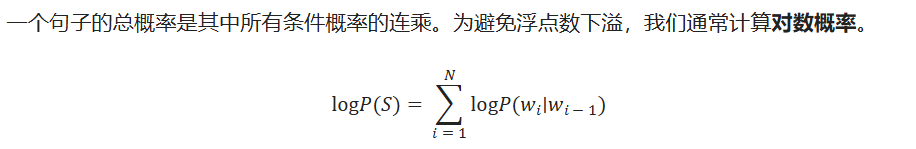

In [15]:
def calc_bigram_prob(sent):
    """使用训练好的二元模型计算句子的对数概率。"""
    sent = ['<BOS>'] + sent + ['<EOS>']
    log_prob = 0.0
    
    for w1, w2 in bigrams(sent):
        # 如果w1从未出现过，或者(w1, w2)从未出现过
        total_count = unigram_counts.get(w1, 0)
        prob = bigram_probs[w1].get(w2, 1 / (total_count + vocab_size))
        log_prob += log(prob)
        
    return log_prob
# --- 比较不同句子的概率 ---
sent1 = ['人们', '常', '说', '生活', '是', '一', '部', '教科书']
sent2 = ['人们', '常', '说', '生活', '教科书', '是', '一', '部'] # 语序错误
prob1 = calc_bigram_prob(sent1)
prob2 = calc_bigram_prob(sent2)
print(f"\n句子 '{' '.join(sent1)}' 的对数概率: {prob1:.4f}")
print(f"句子 '{' '.join(sent2)}' 的对数概率: {prob2:.4f}")
print(f"通顺的句子概率更高: {prob1 > prob2}")
sent3 = ['我', '刚', '吃', '过', '晚饭']
sent4 = ['刚', '我', '过', '晚饭', '吃'] # 语序严重错误
prob3 = calc_bigram_prob(sent3)
prob4 = calc_bigram_prob(sent4)
print(f"\n句子 '{' '.join(sent3)}' 的对数概率: {prob3:.4f}")
print(f"句子 '{' '.join(sent4)}' 的对数概率: {prob4:.4f}")
print(f"通顺的句子概率更高: {prob3 > prob4}")


句子 '人们 常 说 生活 是 一 部 教科书' 的对数概率: -78.3382
句子 '人们 常 说 生活 教科书 是 一 部' 的对数概率: -79.3190
通顺的句子概率更高: True

句子 '我 刚 吃 过 晚饭' 的对数概率: -56.3904
句子 '刚 我 过 晚饭 吃' 的对数概率: -63.9280
通顺的句子概率更高: True


## 第二部分：三元语法模型与文本生成

In [16]:
def trigrams(sequence, pad_left=False, pad_right=False, pad_symbol=None):
    """
    从一个序列中生成三元组 (trigrams)。
    Args:
        sequence: 词列表。
        pad_left: 是否在句首添加填充符 (会添加两个)。
        pad_right: 是否在句尾添加填充符 (会添加两个)。
        pad_symbol: 用于填充的符号。
    Returns:
        一个包含三元组的生成器 (generator)。
    """
    sent = list(sequence)
    # 三元模型的左填充需要在句首插入两个填充符
    if pad_left:
        sent.insert(0, pad_symbol)
        sent.insert(0, pad_symbol)
    # 三元模型的右填充需要在句尾追加两个填充符
    if pad_right:
        sent.append(pad_symbol)
        sent.append(pad_symbol)
    # 遍历列表直到倒数第三个元素，以确保总能形成一个三元组
    for i in range(len(sent) - 2):
        yield (sent[i], sent[i+1], sent[i+2])

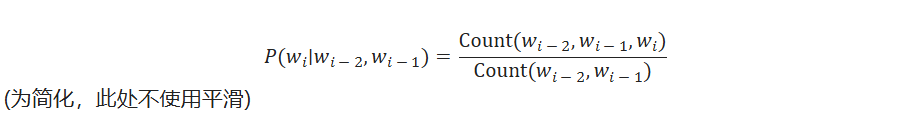

In [17]:
# trigram_probs: 存储 P(w3 | w1, w2)，格式: {(w1, w2): {w3: prob}}
trigram_probs = defaultdict(lambda: defaultdict(float))
# bigram_counts_for_trigram: 存储 Count(w1, w2)，格式: {(w1, w2): count}
bigram_counts_for_trigram = defaultdict(int)
print("\n开始训练三元模型...")
with open(msr_train, encoding="utf-8") as f:
    sents = [line.strip().split("  ") for line in f if line.strip()]
    sents = [['<BOS>'] + sent + ['<EOS>'] for sent in sents]
    
    for sent in sents:
        for w1, w2, w3 in trigrams(sent):
            trigram_probs[(w1, w2)][w3] += 1
        for w1, w2 in bigrams(sent):
            bigram_counts_for_trigram[(w1, w2)] += 1
# 计算条件概率
for (w1, w2), w3_counts in trigram_probs.items():
    total_count = bigram_counts_for_trigram[(w1, w2)]
    for w3, count in w3_counts.items():
        trigram_probs[(w1, w2)][w3] = count / total_count
print("三元模型训练完成！")


开始训练三元模型...
三元模型训练完成！


In [18]:
import random
def generate_sentence(first_word, second_word, length=10):
    """使用三元模型生成句子。"""
    sentence = [first_word, second_word]
    current_w1, current_w2 = first_word, second_word
    
    for _ in range(length):
        # 获取以 (w1, w2) 开头的所有可能的三元组的概率分布
        next_word_probs = trigram_probs.get((current_w1, current_w2))
        
        if not next_word_probs:
            break # 如果这个词对后面没有跟任何词，则停止生成
            
        words, probs = zip(*next_word_probs.items())
        
        # 根据概率分布随机选择下一个词
        next_word = random.choices(words, weights=probs, k=1)[0]
        sentence.append(next_word)
        
        # 更新窗口
        current_w1, current_w2 = current_w2, next_word
        
    return " ".join(sentence)
print("\n--- 使用三元模型生成句子 ---")
print(generate_sentence("科技", "发展"))
print(generate_sentence("中国", "经济"))
print(generate_sentence("计算机", "科学"))


--- 使用三元模型生成句子 ---
科技 发展 农业 生产 是 近 ３个月 以来 跌幅 最大 的 ３４岁
中国 经济 的 条款 ， 从而 限制 了 消费 税 “ 两
计算机 科学


## 第三部分：模型评测——困惑度

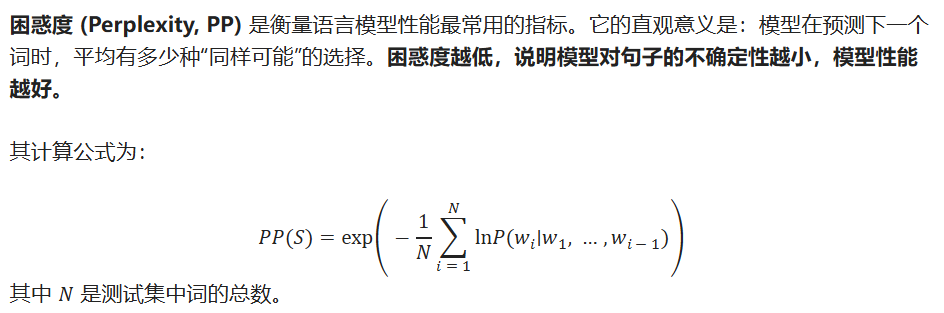

In [19]:
def calculate_trigram_perplexity(test_sents):
    """在测试集上计算三元模型的困惑度。"""
    log_prob_sum = 0.0
    word_count = 0
    
    print("\n开始计算测试集困惑度...")
    
    for sent in test_sents:
        sent = ['<BOS>'] + sent + ['<EOS>']
        word_count += len(sent) - 1 # 不计<BOS>
        
        for w1, w2, w3 in trigrams(sent):
            # 获取 P(w3 | w1, w2)
            total_bigram_count = bigram_counts_for_trigram.get((w1, w2), 0)
            
            # 使用简单的平滑处理测试集中的OOV (Out-of-Vocabulary)
            # 如果分母为0或分子为0，则赋予一个极小的概率
            prob = trigram_probs[(w1, w2)].get(w3, 1 / (total_bigram_count + vocab_size))
            if prob == 0:
                prob = 1 / (total_bigram_count + vocab_size)
            log_prob_sum += log(prob)
            
    # 计算平均对数概率
    avg_log_prob = log_prob_sum / word_count
    # 计算困惑度
    perplexity = exp(-avg_log_prob)
    return perplexity
# 在MSR黄金标准测试集上计算困惑度
with open(msr_gold, encoding="utf-8") as f:
    test_sents = [line.strip().split("  ") for line in f if line.strip()]
perplexity = calculate_trigram_perplexity(test_sents)
print(f"MSR测试集上的三元模型困惑度 (Perplexity): {perplexity:.4f}")


开始计算测试集困惑度...
MSR测试集上的三元模型困惑度 (Perplexity): 3543.2223


## 作业与思考

### 1. 实现一元模型 (Unigram Model)：
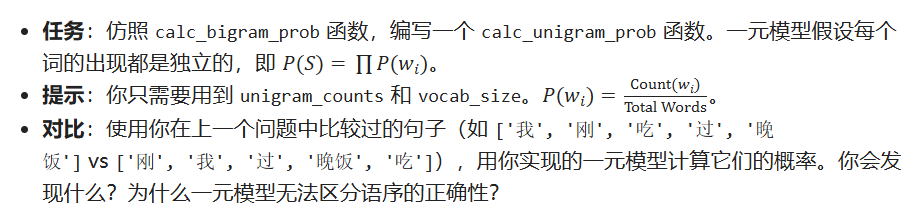

In [20]:
def calc_unigram_prob(sent):
    """使用一元模型计算句子的对数概率。"""
    total_words = sum(unigram_counts.values())
    log_prob = 0.0

    for w in sent:
        # 按提示使用 unigram_counts 和词表大小；对未登录词给一个极小平滑概率
        prob = unigram_counts.get(w, 0) / total_words
        if prob == 0:
            prob = 1 / (total_words + vocab_size)
        log_prob += log(prob)

    return log_prob


# --- 用一元模型对比句子概率 ---
sent_u1 = ['我', '刚', '吃', '过', '晚饭']
sent_u2 = ['刚', '我', '过', '晚饭', '吃']  # 与 sent_u1 词相同但语序不同

u_prob1 = calc_unigram_prob(sent_u1)
u_prob2 = calc_unigram_prob(sent_u2)

print("--- 一元模型结果 ---")
print(f"句子 '{' '.join(sent_u1)}' 的对数概率: {u_prob1:.8f}")
print(f"句子 '{' '.join(sent_u2)}' 的对数概率: {u_prob2:.8f}")
print(f"两句概率是否相同: {abs(u_prob1 - u_prob2) < 1e-12}")

print("\n结论：")
print("一元模型把句子概率分解为各词独立概率的乘积，只看‘用了哪些词’和词频，不看词序。")
print("因此对由同一组词组成、仅语序不同的句子，一元模型会给出相同概率，无法区分语序正确性。")

--- 一元模型结果 ---
句子 '我 刚 吃 过 晚饭' 的对数概率: -43.91598579
句子 '刚 我 过 晚饭 吃' 的对数概率: -43.91598579
两句概率是否相同: True

结论：
一元模型把句子概率分解为各词独立概率的乘积，只看‘用了哪些词’和词频，不看词序。
因此对由同一组词组成、仅语序不同的句子，一元模型会给出相同概率，无法区分语序正确性。


### 2. 平滑技术的重要性：

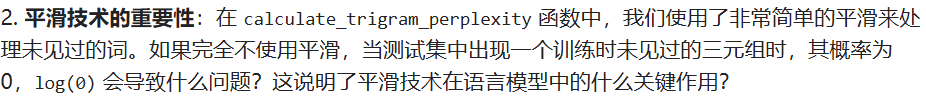

如果完全不使用平滑，测试集中一旦出现训练时从未见过的三元组（或某个条件概率为 0），就会出现：

- 该三元组概率 $P(w_3\mid w_1,w_2)=0$
- 于是 $\log(0)=-\infty$，代码里对数概率累加会直接变成 $-\infty$
- 最终整句（甚至整个测试集）的总对数概率会被“一个 0 概率事件”彻底拉垮，困惑度 $PP=\exp\!\left(-\frac{1}{N}\sum \log P\right)$ 会变成 $\exp(+\infty)=+\infty$（或数值上报错/得到 inf）

这说明平滑在语言模型中的关键作用是：

- 给未见过的事件分配一个**非零的小概率**，避免 $\log(0)$ 导致的无穷值和评测崩溃
- 让模型对测试集中的“新组合/新词”更鲁棒，提升泛化能力（避免把训练集当成唯一世界）
- 从概率角度看，是把一部分概率质量从已见事件“挪”到未见事件，使模型成为可用的、可评测的概率分布

### 3. 模型的局限性：

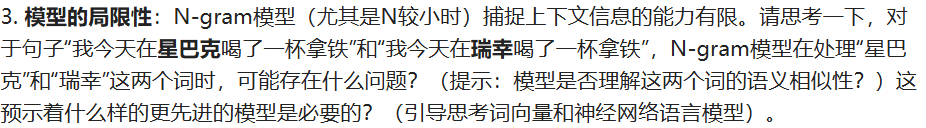

N-gram（尤其 N 较小如 2-gram/3-gram）在处理“星巴克”和“瑞幸”这类词时，主要问题是：

- 只会把它们当作两个“离散符号”，不理解语义相似性  
  对模型来说，“星巴克”和“瑞幸”只是不同 token，没有“都是咖啡品牌/饮品店”的语义联系；因此即使上下文“我今天在__喝了一杯拿铁”很像，只要训练里“在 瑞幸 喝/买/点 拿铁”出现少或没出现，概率仍可能很低。

- 数据稀疏 + 未登录组合导致泛化差  
  小 N 的模型靠统计局部片段频次。如果训练集中“在 星巴克 喝”很多，“在 瑞幸 喝”很少，那么它会偏向“星巴克”而不敢给“瑞幸”高概率；更极端时会遇到没见过的 n-gram，导致强依赖平滑但仍不“懂”含义。

- 上下文窗口有限，无法利用更长依赖/语义线索  
  N-gram 只能看最近 N−1 个词，无法用更远处信息或句子级语义来帮助判断“瑞幸/星巴克”在该语境里都合理。

这预示更先进模型的必要性：

- 词向量/分布式表示（word2vec、GloVe、fastText等）：把词映射到连续向量空间，能让“星巴克”和“瑞幸”在向量上更接近，从而把在一个词上学到的上下文偏好迁移到语义相近词上。  
- 神经网络语言模型（RNN/LSTM/Transformer）：用连续表示 + 更强的上下文建模能力，既缓解稀疏问题，又能捕捉更长距离依赖，并通过相似词的表示实现更好的泛化。